# Task 1 : Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

# Task 2 : Importing Dataset

In [2]:
df = pd.read_csv('Online Retail.csv' , encoding = 'unicode_escape')

# Task 3 : Exploring Dataset

In [3]:
# Finding the number of columns and rows

print(f'Dataset : {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset : 541,909 rows x 8 columns


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [5]:
df.sample()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
416861,572562,21790,VINTAGE SNAP CARDS,12,25-10-2011 09:07,0.85,13481.0,United Kingdom


In [6]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [7]:
# Exploring the datatypes of columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Task 4 : Data Cleaning

In [8]:
# finding null values

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# finding duplicate entries

df.duplicated().sum()

np.int64(5268)

In [10]:
# making a copy of our dataset

temp = df.copy()

In [11]:
temp.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [12]:
# removing duplicate values

temp.drop_duplicates(inplace=True)

In [13]:
temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  object 
 1   StockCode    536641 non-null  object 
 2   Description  535187 non-null  object 
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  object 
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 36.8+ MB


In [14]:
# removing null values on the basis of CustomerID column

temp.dropna(subset = ['CustomerID'], inplace=True)

In [15]:
temp.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [16]:
print(f'Total number of txn after data cleaning = {temp.shape[0]:,}')

Total number of txn after data cleaning = 401,604


In [17]:
# Removing the StockCode column
temp.drop(columns = 'StockCode', inplace = True)

# Task 5 : Statistical Analysis

In [18]:
# checking for outliers in Quantity column

temp['Quantity'].value_counts().sort_index()

Quantity
-80995    1
-74215    1
-9360     1
-3114     1
-2000     1
         ..
 4300     1
 4800     1
 12540    1
 74215    1
 80995    1
Name: count, Length: 436, dtype: int64

In [19]:
# defining q1, q2, IQR, lf, uf

q1 = np.percentile(temp['Quantity'],25)
q3 = np.percentile(temp['Quantity'],75)
IQR = q3-q1
lf = q1-1.5*IQR
uf = q3+1.5*IQR

In [20]:
print(f'Interquartile range(IQR) = {IQR}\n Lower Fence(lf) = {lf}\n Upper Fence = {uf}')

Interquartile range(IQR) = 10.0
 Lower Fence(lf) = -13.0
 Upper Fence = 27.0


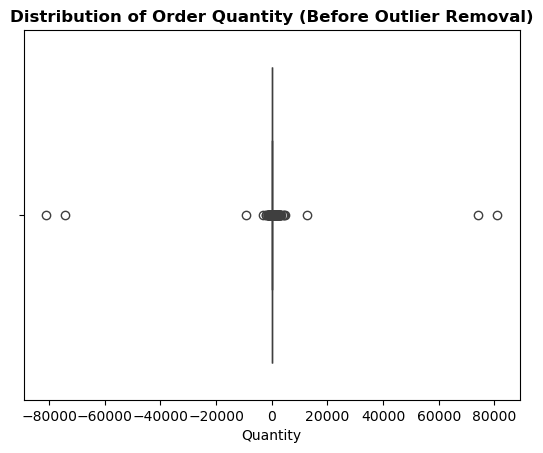

In [21]:
# boxplot for detecting outliers 

sns.boxplot(data = temp, x = 'Quantity')
plt.title('Distribution of Order Quantity (Before Outlier Removal)', fontsize = 12, fontweight = 'bold')
plt.show()

In [22]:
# removing outliers

temp = temp[(temp['Quantity'] >= lf) & (temp['Quantity'] <= uf)]

In [23]:
temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 374958 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    374958 non-null  object 
 1   Description  374958 non-null  object 
 2   Quantity     374958 non-null  int64  
 3   InvoiceDate  374958 non-null  object 
 4   UnitPrice    374958 non-null  float64
 5   CustomerID   374958 non-null  float64
 6   Country      374958 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 22.9+ MB


In [24]:
temp.describe()

,Quantity,UnitPrice,CustomerID
count,374958.000000,374958.000000,374958.000000
mean,6.880915,3.614262,15296.014255
std,6.776924,72.189462,1712.757792
min,-13.000000,0.000000,12347.000000
25%,2.000000,1.250000,13969.000000
50%,4.000000,1.950000,15159.000000
75%,12.000000,3.750000,16800.000000
max,27.000000,38970.000000,18287.000000


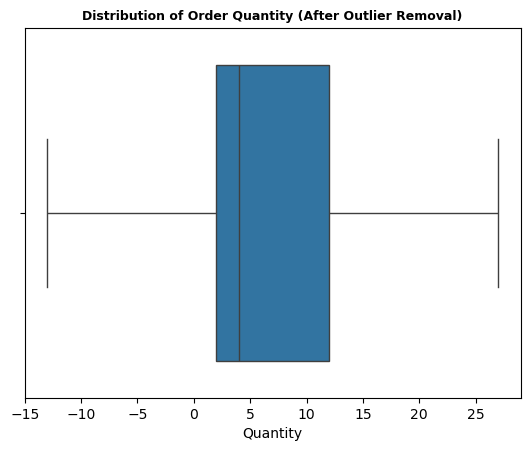

In [25]:
# boxplot after removing outliers

sns.boxplot(data = temp, x = 'Quantity')
plt.title('Distribution of Order Quantity (After Outlier Removal)', fontsize = 9, fontweight = 'bold')
plt.show()

In [26]:
temp['Quantity'].value_counts().sort_index()

Quantity
-13       16
-12      517
-11       45
-10      164
-9        47
-8       143
-7        81
-6       468
-5       186
-4       454
-3       576
-2      1326
-1      3828
 1     69605
 2     57425
 3     26817
 4     32093
 5      8100
 6     37480
 7      1296
 8     11594
 9      1169
 10    21161
 11      341
 12    59828
 13      200
 14      237
 15      447
 16     3945
 17       73
 18     1556
 19       71
 20     4761
 21       65
 22       60
 23       30
 24    23694
 25     4976
 26       36
 27       47
Name: count, dtype: int64

In [27]:
temp['Quantity'].value_counts().sort_values()

Quantity
-13       16
 23       30
 26       36
-11       45
 27       47
-9        47
 22       60
 21       65
 19       71
 17       73
-7        81
-8       143
-10      164
-5       186
 13      200
 14      237
 11      341
 15      447
-4       454
-6       468
-12      517
-3       576
 9      1169
 7      1296
-2      1326
 18     1556
-1      3828
 16     3945
 20     4761
 25     4976
 5      8100
 8     11594
 10    21161
 24    23694
 3     26817
 4     32093
 6     37480
 2     57425
 12    59828
 1     69605
Name: count, dtype: int64

# Task 6 : Exploratory Data Analysis

In [28]:
# Feature Engineering
# 1. Adding TotalAmount Column

temp['TotalAmount'] = temp['UnitPrice']*temp['Quantity']

In [29]:
# 2. Adding Status column

temp['Status'] = np.where(temp['InvoiceNo'].astype(str).str.startswith('C'), 'Cancelled', 'Success')

In [30]:
# 3. Changing the datatype of CustomerID

temp['CustomerID'] = temp['CustomerID'].astype('str')

In [31]:
# 4 Changing the datatype of InvoiceDate

temp['InvoiceDate'] = pd.to_datetime(temp['InvoiceDate'], format='%d-%m-%Y %H:%M')

In [32]:
# 5. extracting year_month from datetime object
temp['Year_Month'] = temp['InvoiceDate'].dt.to_period('M')

In [33]:
# 6. extracting dayname from datetime object
temp['dayname'] = temp['InvoiceDate'].dt.day_name()

In [34]:
print(f'The total number of transaction = {temp.shape[0]:,}')
print(f'Total number of successful transaction = {temp[temp['Status']=='Success'].shape[0]:,}')
print(f'Total number of cancelled transaction = {temp[temp['Status']=='Cancelled'].shape[0]:,}')
print(f'Total number of unique products = {temp['Description'].nunique():,}')
print(f'Total number of unique customers = {temp['CustomerID'].nunique():,}')
print(f'Total number of unique countries = {temp['Country'].nunique():,}')
print(f'Total net revenue  = ${temp['TotalAmount'].sum():,.2f}')
print(f'Average order value = ${temp['TotalAmount'].mean():,.2f}')

The total number of transaction = 374,958
Total number of successful transaction = 367,107
Total number of cancelled transaction = 7,851
Total number of unique products = 3,871
Total number of unique customers = 4,274
Total number of unique countries = 37
Total net revenue  = $5,107,675.86
Average order value = $13.62


# Monthly Revenue Trend 

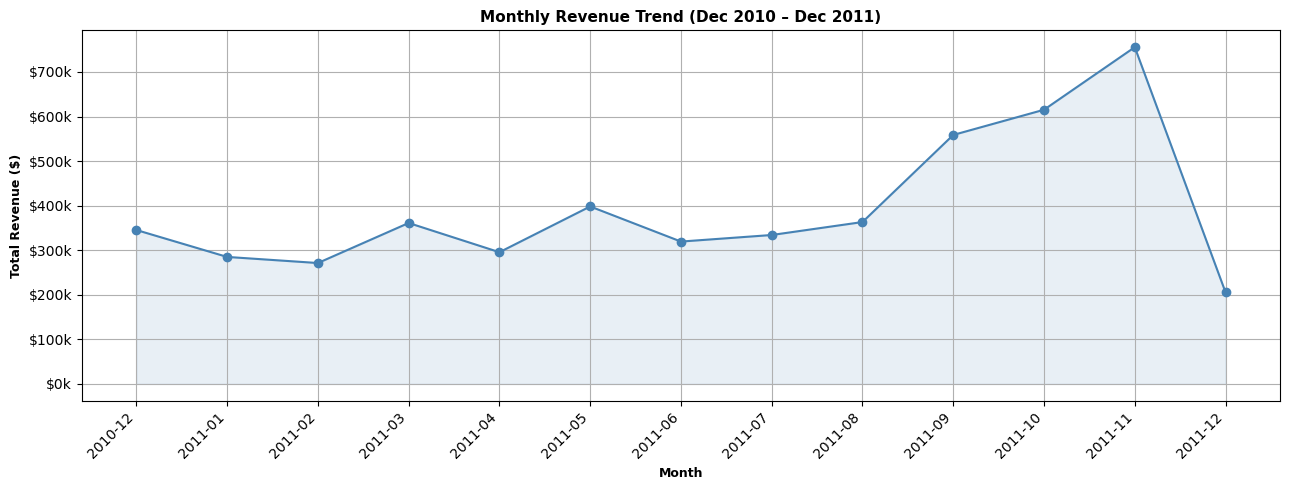

In [35]:
monthly_trend = temp.groupby('Year_Month')['TotalAmount'].sum().reset_index()
monthly_trend['Year_Month'] = monthly_trend['Year_Month'].astype(str)

fig, ax = plt.subplots(figsize = (13, 5))

ax.plot(monthly_trend['Year_Month'], monthly_trend['TotalAmount'], marker = 'o', linewidth = 1.5, color = 'steelblue', markersize = 6)
ax.fill_between(range(len(monthly_trend)), monthly_trend['TotalAmount'], alpha = 0.12, color = 'steelblue')
ax.set_xticks(range(len(monthly_trend)))
ax.set_xticklabels(monthly_trend['Year_Month'], rotation = 45, ha = 'right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:,.0f}k'))
ax.set_title('Monthly Revenue Trend (Dec 2010 – Dec 2011)', fontsize = 11, fontweight = 'bold')
ax.set_xlabel('Month', fontsize = 9, fontweight = 'bold')
ax.set_ylabel('Total Revenue ($)', fontsize = 9, fontweight = 'bold')

plt.grid()
plt.tight_layout()
plt.show()

* ***November 2011** showed the **highest sales of ~755,605.4 USD**, indicating high seasonal demand.*
* *From **August 2011-November 2011**, sales showed **significant growth**, implying shopping season.*
* ***December 2011** showed the **least sales of ~205,494.1 USD**.*

# Daywise Revenue and spend

In [36]:
dayily_rev = temp.groupby('dayname').agg(total_rev = ('TotalAmount', 'sum'),                                       
                                         customers = ('CustomerID', 'nunique')).reset_index()

dayily_rev['avg_by_cust'] = dayily_rev['total_rev']/dayily_rev['customers']

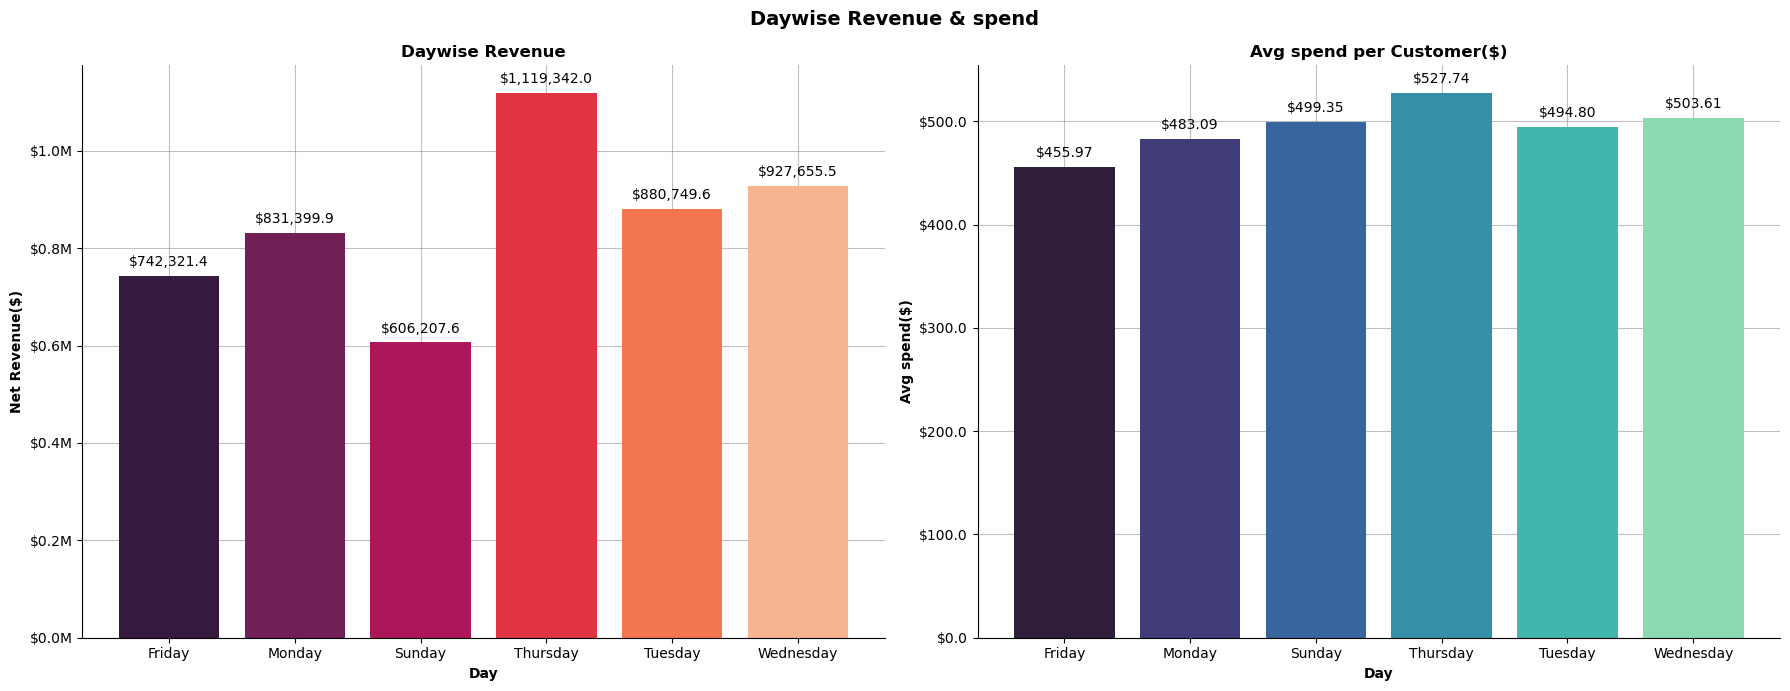

In [37]:
fig, ax = plt.subplots(1, 2, figsize = (18, 7))
for single_ax in ax.flatten():
    # Keep only bottom (x) and left (y) axis lines
    single_ax.spines['top'].set_visible(False)
    single_ax.spines['right'].set_visible(False)
    
    # Gridlines
    single_ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
    single_ax.set_axisbelow(True)

# total revenue per day
b1 = ax[0].bar(dayily_rev['dayname'], dayily_rev['total_rev'], color = sns.color_palette('rocket', 6))
ax[0].set_title('Daywise Revenue', fontsize = 12, fontweight = 'bold')
ax[0].set_ylabel('Net Revenue($)', fontsize = 10, fontweight = 'bold')
ax[0].set_xlabel('Day', fontsize = 10, fontweight = 'bold')
ax[0].bar_label(b1, labels = [f'${v:,.1f}' for v in dayily_rev['total_rev']], padding = 5)
ax[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:,.1f}M'))

# Avg spend per day 
b2 = ax[1].bar(dayily_rev['dayname'], dayily_rev['avg_by_cust'], color = sns.color_palette('mako'))
ax[1].set_title('Avg spend per Customer($)', fontsize = 12, fontweight = 'bold')
ax[1].set_ylabel('Avg spend($)', fontsize = 10, fontweight = 'bold')
ax[1].set_xlabel('Day', fontsize = 10, fontweight = 'bold')
ax[1].bar_label(b2, labels = [f'${v:,.2f}' for v in dayily_rev['avg_by_cust']], padding = 5)
ax[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.1f}'))

plt.suptitle('Daywise Revenue & spend', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

* *People **spend more on Thursday**, both **normally & averagely, ~1.1M USD & ~528 USD** And more people shop on Thursday.*
* ***Sunday** showed the **least sales of ~606k USD**, but showed good **avg spend of ~499 USD**, indicating **less people shop** on Sunday, but **buy a little expensive items**.*
* ***Friday** showed the **least average per customer ~(456 USD)**, showed **2nd least** shopping day after Sunday.*
* ***No one shop on Saturday**.*

# Geographic Revenue

In [38]:
country_info = temp.groupby('Country').agg(total_rev = ('TotalAmount', 'sum'),                                       
                                           customers = ('CustomerID', 'nunique')).reset_index()

country_info['avg_country'] = country_info['total_rev']/country_info['customers']

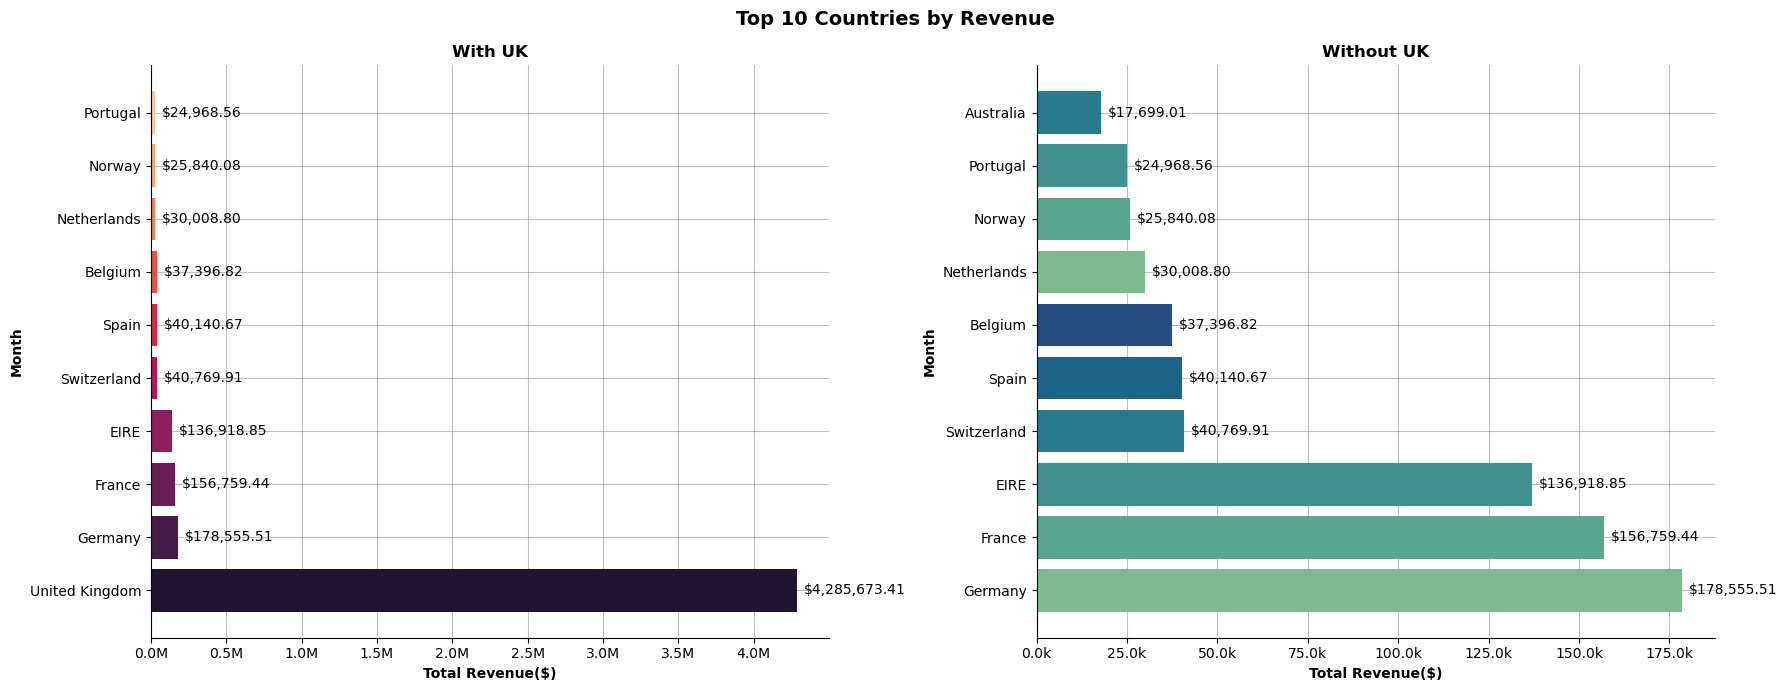

In [39]:
# with uk
top10_countries_rev = country_info.sort_values('total_rev', ascending = False).head(10)

# without uk
country_info_no_uk = country_info[country_info['Country'] != 'United Kingdom']
top10_countries_rev_no_uk = country_info_no_uk.sort_values('total_rev', ascending = False).head(10)

fig, ax = plt.subplots(1, 2, figsize = (18, 7))
for single_ax in ax.flatten():
    # Keep only bottom (x) and left (y) axis lines
    single_ax.spines['top'].set_visible(False)
    single_ax.spines['right'].set_visible(False)
    
    # Gridlines
    single_ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
    single_ax.set_axisbelow(True)

# top 10 total revenue
r1 = ax[0].barh(top10_countries_rev['Country'], top10_countries_rev['total_rev'], color = sns.color_palette('rocket', 10))
ax[0].set_title('With UK', fontsize = 12, fontweight = 'bold')
ax[0].set_xlabel('Total Revenue($)', fontsize = 10, fontweight = 'bold')
ax[0].set_ylabel('Month', fontsize = 10, fontweight = 'bold')
ax[0].bar_label(r1, labels = [f'${v:,.2f}' for v in top10_countries_rev['total_rev']], padding = 5)
ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:,.1f}M'))

# top 10 total revenue(without UK)
r2 = ax[1].barh(top10_countries_rev_no_uk['Country'], top10_countries_rev_no_uk['total_rev'], color = sns.color_palette('crest'))
ax[1].set_title('Without UK', fontsize = 12, fontweight = 'bold')
ax[1].set_xlabel('Total Revenue($)', fontsize = 10, fontweight = 'bold')
ax[1].set_ylabel('Month', fontsize = 10, fontweight = 'bold')
ax[1].bar_label(r2, labels = [f'${v:,.2f}' for v in top10_countries_rev_no_uk['total_rev']], padding = 5)
ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:,.1f}k'))


plt.suptitle('Top 10 Countries by Revenue', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

***With UK***
* ***UK's** revenue of **~4.28M USD** completely dwarfs every other country*. 
* ***Germany** is **second** at just **~178k USD** — meaning **UK** alone accounts for roughly **90%+ of total revenue**.*

***Without UK***
* ***Germany (~178k USD)** and **France (~156k USD)** are the clear **top 2 international markets** — worth prioritising for marketing spend.*
* ***EIRE (~136k USD)** is **strong** given Ireland's relatively **small population** — suggests **high customer loyalty or strong brand presence** there.*
* ***Switzerland (~40k USD)** despite being a small country punches above its weight compared to larger European nations like Netherlands (~30k USD) — **Swiss customers likely have higher purchasing power**.*
* ***Australia (~17k USD)** appearing in the **top 10** is interesting — it's not a neighbouring country, meaning **demand exists organically without much geographic proximity advantage**.*

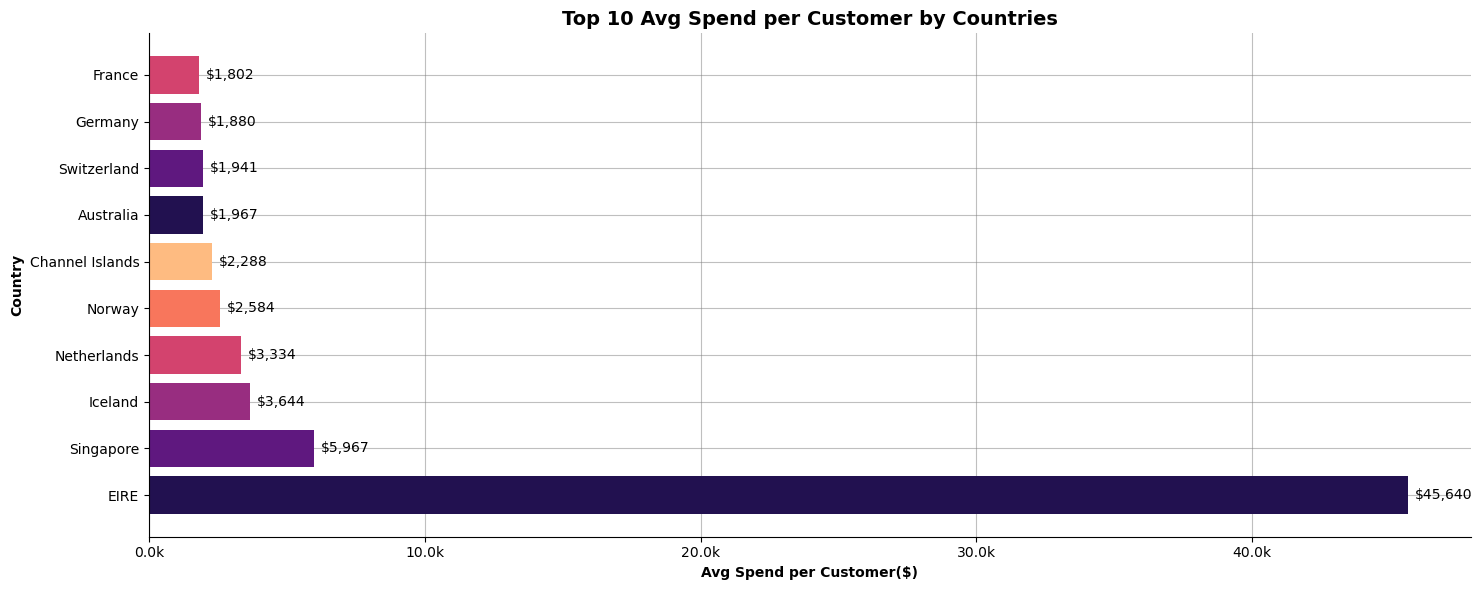

In [40]:
# top 10 Avg Spend per Customer by Country

top10_countries_avg = country_info.sort_values('avg_country', ascending = False).head(10)

fig, ax = plt.subplots(figsize = (15, 6))
ax = plt.gca()
# Keep only bottom (x) and left (y) axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Gridlines
ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
ax.set_axisbelow(True)
    
r3 = ax.barh(top10_countries_avg['Country'], top10_countries_avg['avg_country'], color = sns.color_palette('magma'))
ax.set_title('Top 10 Avg Spend per Customer by Countries', fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Avg Spend per Customer($)', fontsize = 10, fontweight = 'bold')
ax.set_ylabel('Country', fontsize = 10, fontweight = 'bold')
ax.bar_label(r3, labels = [f'${v:,.0f}' for v in top10_countries_avg['avg_country']], padding = 5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:,.1f}k'))

plt.tight_layout()
plt.show()

* ***EIRE** customers spend on **average 45,640 USD** — nearly **8x higher than the next country** (Singapore at 5,967 USD). With strong total revenue already shown in the previous chart, **EIRE represents the single most valuable customer base outside the UK**.*
* ***Singapore (5,967 USD) and Iceland (3,644 USD)** have surprisingly **high avg spend** for small, distant markets — these **customers** are likely **business buyers placing bulk orders, not individual shoppers**.*
* ***Netherlands (3,334 USD) beats** larger neighbours like **Germany (1,880 USD) and France (1,802 USD)** on per-customer value despite similar total revenue — **quality of customers is higher**.*
* ***Germany and France** appear at the **bottom** of this top-10 list — they have **high total revenue** but **low avg spend**, meaning they have many **low-value customers** rather than fewer high-value ones.*

# Customer Analysis

In [41]:
# Customer-wise Transaction Count & Total Spend

txn_info = temp.groupby('CustomerID').agg(total_txn = ('InvoiceNo', 'count'), 
                                          total_spend = ('TotalAmount', 'sum')).reset_index()

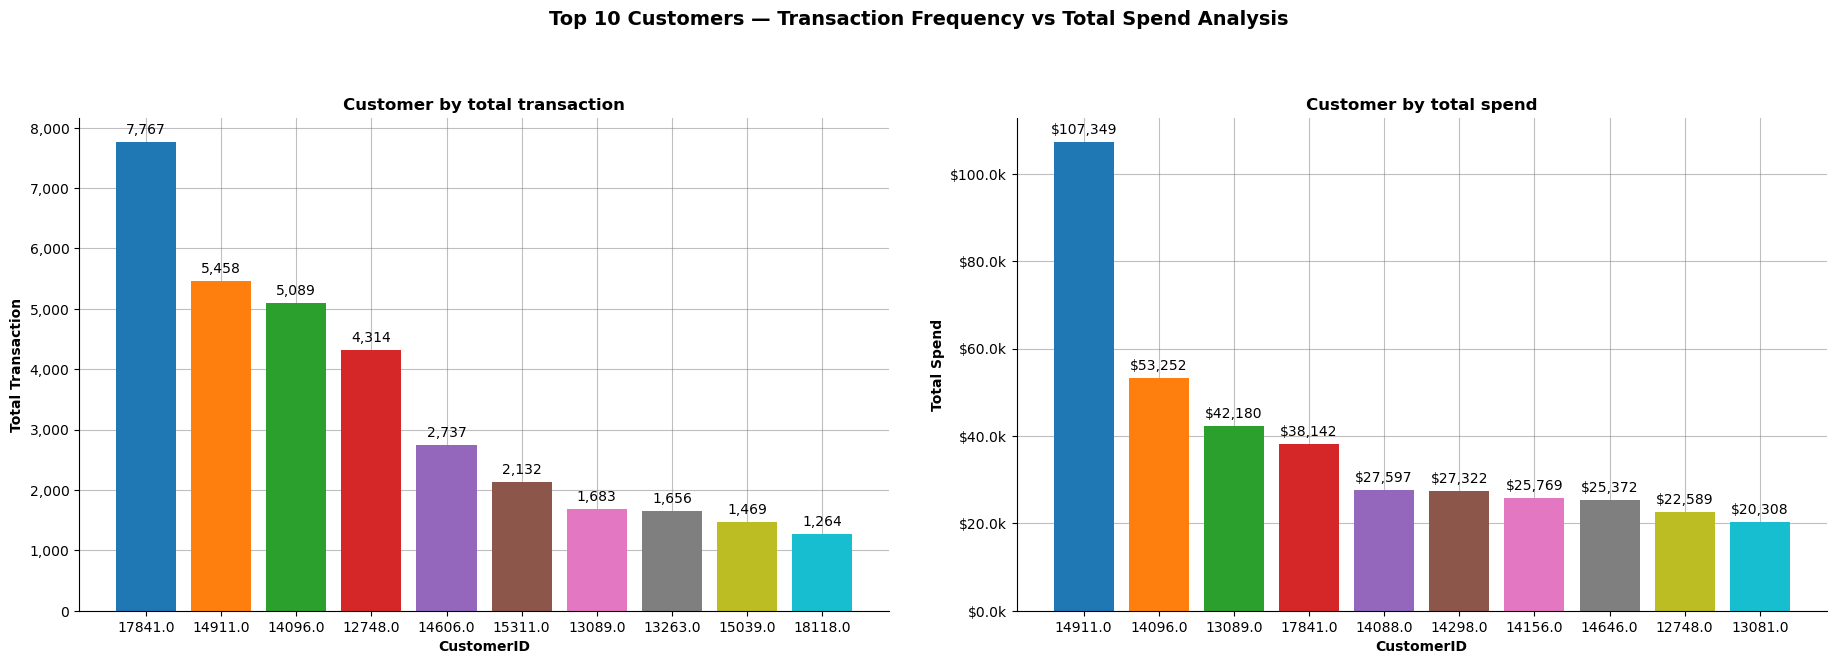

In [42]:
# top 10 most transaction vs most spend by customer

# Top 10 Customers by Transactions
top10_txn = txn_info.sort_values('total_txn', ascending = False).head(10)

# Top 10 Customers by Total Spend
top10_spend = txn_info.sort_values('total_spend', ascending = False).head(10)

fig, ax = plt.subplots(1, 2, figsize = (19, 7))
for single_ax in ax.flatten():
    # Keep only bottom (x) and left (y) axis lines
    single_ax.spines['top'].set_visible(False)
    single_ax.spines['right'].set_visible(False)
    
    # Gridlines
    single_ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
    single_ax.set_axisbelow(True)


b0 = ax[0].bar(top10_txn['CustomerID'], top10_txn['total_txn'], color = sns.color_palette("tab10"))
ax[0].set_title('Customer by total transaction', fontsize = 12, fontweight = 'bold')
ax[0].set_xlabel('CustomerID', fontsize = 10, fontweight = 'bold')
ax[0].set_ylabel('Total Transaction', fontsize = 10, fontweight = 'bold')
ax[0].bar_label(b0, labels = [f'{v:,.0f}' for v in top10_txn['total_txn']], padding = 4, fontsize = 10)
ax[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))


b1 = ax[1].bar(top10_spend['CustomerID'], top10_spend['total_spend'], color = sns.color_palette())
ax[1].set_title('Customer by total spend', fontsize = 12, fontweight = 'bold')
ax[1].set_xlabel('CustomerID', fontsize = 10, fontweight = 'bold')
ax[1].set_ylabel('Total Spend', fontsize = 10, fontweight = 'bold')
ax[1].bar_label(b1, labels = [f'${v:,.0f}' for v in top10_spend['total_spend']], padding = 4, fontsize = 10)
ax[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:,.1f}k'))

plt.suptitle('Top 10 Customers — Transaction Frequency vs Total Spend Analysis', fontsize = 14, fontweight = 'bold')
plt.tight_layout(pad = 3.0)
plt.show()

* ***CustomerID 17841.0 purchased** the **most with 7,767 transactions**, followed by **14911.0 and 14096.0** with **5,458 and 5,089 orders** respectively.*
* ***CustomerID 14911.0 spends** the most with **~107,349 USD**, followed by **14096.0 and 13089.0** with **net spending of 53,252 USD and 42,180 USD** respectively.*
* *This **indicates** that although **ID 17841.0 purchased the most** but focused in **less expensive products**, whereas **ID 14911.0** focused more on **expensive products.***
* *The **top 3 customers** in both graphs shows **their satisfaction and fullfilment**, indicates **they can be treated as premium customers and an additional discount** can be given to them.*

# Product Analysis

In [43]:
# Product-wise Units Sold & Revenue Generated

prod_info = temp.groupby('Description').agg(Total_sold = ('Quantity', 'sum'), 
                                            total_amt = ('TotalAmount', 'sum')).reset_index()

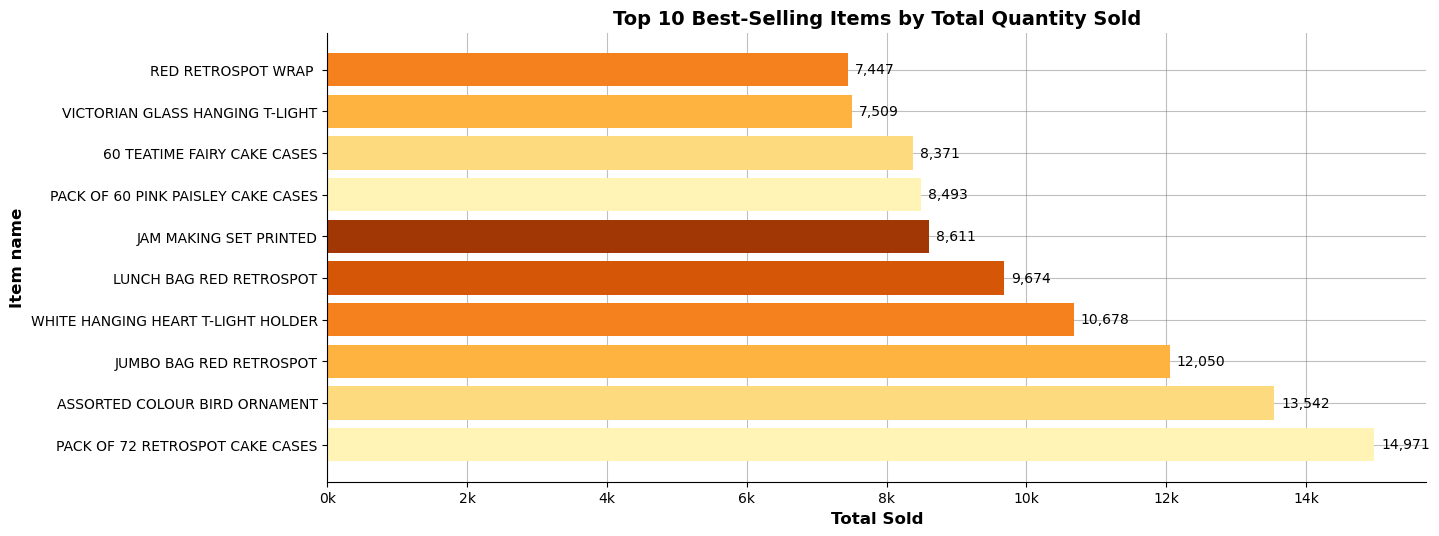

In [44]:
# Top 10 Best-Selling Products by Quantity
top10_sold_items = prod_info.sort_values('Total_sold', ascending = False).head(10)


fig, ax = plt.subplots(figsize = (15, 6))
ax = plt.gca()
# Keep only bottom (x) and left (y) axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Gridlines
ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
ax.set_axisbelow(True)

bh1 = ax.barh(top10_sold_items['Description'], top10_sold_items['Total_sold'], color = sns.color_palette('YlOrBr'))
ax.set_title('Top 10 Best-Selling Items by Total Quantity Sold', fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Total Sold', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Item name', fontsize = 12, fontweight = 'bold')
ax.bar_label(bh1, labels = [f'{v:,.0f}' for v in top10_sold_items['Total_sold']], padding = 5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:,.0f}k'))

plt.tight_layout(pad = 3.0)
plt.show()

* ***PACK OF 72 RETROSPOT CAKE CASES** is the best selling product with **14,971 units** — nearly 1,300 units ahead of the second place.*
* ***ASSORTED COLOUR BIRD ORNAMENT** and **JUMBO BAG RED RETROSPOT** are strong runners up at **13,542** and **12,050 units**.*

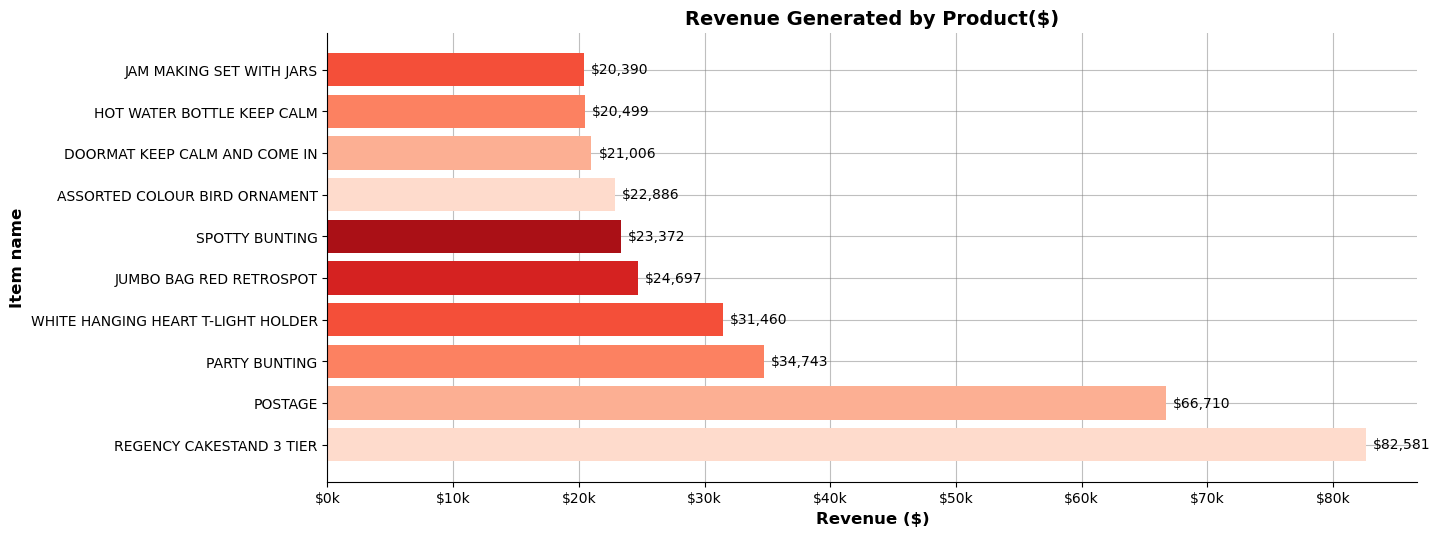

In [45]:
# Top 10 Products by Revenue Generated
top10_sold_items_amt = prod_info.sort_values('total_amt', ascending = False).head(10)

fig, ax = plt.subplots(figsize = (15, 6))
ax = plt.gca()
# Keep only bottom (x) and left (y) axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Gridlines
ax.grid(True, axis = 'both', linestyle = 'solid', alpha = 0.5, color = 'gray')
ax.set_axisbelow(True)

bh2 = ax.barh(top10_sold_items_amt['Description'], top10_sold_items_amt['total_amt'], color = sns.color_palette('Reds'))
ax.set_title('Revenue Generated by Product($)', fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Revenue ($)', fontsize = 12, fontweight = 'bold')
ax.set_ylabel('Item name', fontsize = 12, fontweight = 'bold')
ax.bar_label(bh2, labels = [f'${v:,.0f}' for v in top10_sold_items_amt['total_amt']], padding = 5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e3:,.0f}k'))

plt.tight_layout(pad = 3.0)
plt.show()

* ***REGENCY CAKESTAND 3 TIER** leads with  **82,581 USD**, far ahead of everyone else.*
* ***POSTAGE** being **2nd** highest, **66,710 USD**.*
* ***PARTY BUNTING** entries at **3rd** place, **34,743 USD**.*

# Final Insight

***Final Insights & Recommendations***

***Revenue & Seasonality***
* *Revenue peaked at ~755k USD in November 2011 — a clear holiday shopping surge. The business must plan stock and logistics by September to capitalise on this window.*
* *December 2011 dropped sharply to ~205k USD — either data is incomplete for that month, or post-holiday slowdown is severe.*

***Day-wise Behaviour***
* *Thursday is the power day — highest both in total revenue (1.1M USD) and avg spend per customer (~528 USD). Marketing campaigns and promotions should be timed around Thursday.*
* *Sunday shoppers buy less frequently but spend more per visit — a good target for premium product promotions.*
* *No transactions on Saturday — this is unusual and worth investigating.*

***Geographic***
* *UK contributes 90%+ of total revenue — the business is dangerously concentrated in one market. Any disruption to UK operations directly threatens the entire business.*
* *Germany and France are the most viable international expansion targets by total volume.*
* *EIRE has the highest avg spend per customer at ~45,640 USD — even if this is driven by a few bulk buyers, these accounts must be protected and nurtured as VIP clients.*
* *Netherlands outperforms Germany and France on avg spend per customer despite lower total revenue — higher quality customer base worth targeted investment.*

***Customer Behaviour***
* *CustomerID 17841 places the most orders (7,767) but spends less per order — a high-frequency, low-value buyer.*
* *CustomerID 14911 spends the most overall (~107k USD) — a true VIP. These top 3 spenders deserve exclusive loyalty benefits and personal discounts to retain them.*
* *The split between "most transactions" and "most spend" customers confirms that transaction count alone is a poor proxy for customer value — always look at monetary value too.*

***Product***
* *REGENCY CAKESTAND 3 TIER is the top revenue product at ~82k USD — never let this go out of stock.*
* *PACK OF 72 RETROSPOT CAKE CASES leads in units sold (14,971) but doesn't appear in the top revenue list — it's a high-volume, low-margin item.*
* *POSTAGE appearing as 2nd highest revenue (~66k USD)*

***The business is seasonal, UK-dependent, and driven by a small number of high-value customers and products — all three of these concentrations represent both a strength to protect and a risk to mitigate.***